<details>
<summary>Customer Churn Prediction – Project Overview (Click to Expand)</summary>

## Customer Churn Prediction – Machine Learning Project

### Overview
This notebook builds a Customer Churn Prediction Model using machine learning techniques.  
The goal is to identify customers at risk of leaving a service so businesses can proactively take retention actions.

This project demonstrates a complete end-to-end machine learning workflow, from data preparation to prediction export for use in analytics dashboards such as Power BI.

---

## Project Workflow

### 1️⃣ Data Loading
- Import customer churn dataset  
- Inspect structure and data types  
- Perform initial data exploration

### 2️⃣ Data Cleaning
- Convert incorrect data types  
- Handle missing values  
- Remove non-predictive identifiers

### 3️⃣ Feature Engineering
- Encode categorical variables  
- Prepare dataset for machine learning models

### 4️⃣ Train/Test Split
- Separate training and testing datasets  
- Ensure reliable model evaluation

### 5️⃣ Feature Scaling
- Standardise numerical features using a scaler  
- Improve algorithm performance

### 6️⃣ Model Training
Two machine learning models are trained and compared:

- Logistic Regression  
- Random Forest Classifier  

The best-performing model is selected for predictions.

### 7️⃣ Model Evaluation
Models are evaluated using:

- Accuracy score  
- Confusion matrix  
- Classification report  

These metrics ensure the model performs reliably.

---

## Prediction Outputs

After training, the notebook exports several datasets for analytics and reporting.

### Full Prediction Dataset
customer_churn_predictions_enhanced.csv

Includes:

- Customer ID  
- Actual churn status  
- Predicted churn  
- Churn probability  
- Risk band classification  
- Retention priority  

This dataset is designed for Power BI dashboards and business analytics.

---

### High-Risk Customer List
top_100_high_risk_customers.csv

Identifies customers most likely to churn, enabling businesses to prioritise retention actions.

---

### Model Feature Importance
churn_feature_importance.csv

Shows the most influential factors driving churn predictions, helping explain the model’s decisions.

---

## Business Value

This project demonstrates how machine learning can support real business decision-making by:

- Identifying customers likely to churn  
- Prioritising retention campaigns  
- Highlighting key churn drivers  
- Enabling proactive customer management

---

## Tools & Technologies

- Python  
- Pandas  
- NumPy  
- Scikit-learn  
- Google Colab  

Model outputs can be integrated with Power BI dashboards for interactive reporting and business insights.

---

### Author
Richard McInerney  
Data Analytics & Machine Learning Portfolio Project

</details>

In [1]:
# Cell 1 Import Data From Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [15]:
# Cell 2 Load data into pandas
import pandas as pd

# Load the dataset into a pandas DataFrame
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display basic information about the data
print("Dataset shape:", df.shape)
print("\nPreview of data:")

# Set display options to show all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.head())

# Check for null values and data types
print("\nMissing values:")
print(df.isnull().sum())
print("\nColumn data types:")
print(df.dtypes)

Dataset shape: (7043, 21)

Preview of data:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Column data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMetho

In [3]:
# Cell 3 Data cleaning and correction
import numpy as np

# Keep customer IDs for final prediction export
customer_ids = df['customerID'].copy()

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID as it should not be used for modelling
df.drop('customerID', axis=1, inplace=True)

print("Cleaned dataset preview:")
display(df.head())


Cleaned dataset preview:


/tmp/ipykernel_477/2171723299.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Cell 4 Encode categorical variables and label target variable
from sklearn.preprocessing import LabelEncoder

# Encode the target label 'Churn' as 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)


Encoded dataset shape: (7043, 31)


In [5]:
# Cell 5️ Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 5634
Testing samples: 1409


In [6]:
# Cell 6️ Standardize numerical features for better model performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
# Cell 7️ Train and compare multiple classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    print(f"\n🔹 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))



🔹 Logistic Regression Accuracy: 0.8070
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


🔹 Random Forest Accuracy: 0.7921
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


🔹 Gradient Boosting Accuracy: 0.7984
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg    

/tmp/ipykernel_477/274547989.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


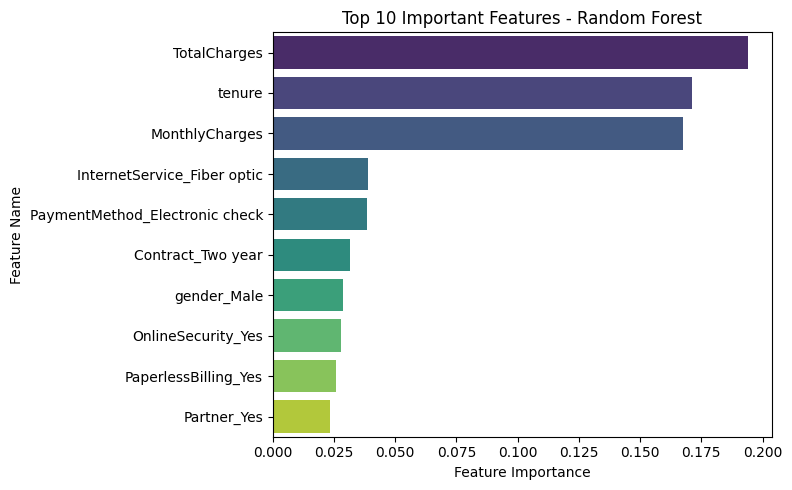

In [8]:
# Cell 8️ Visualize feature importance from the best-performing model (e.g., Random Forest)
import matplotlib.pyplot as plt
import seaborn as sns

rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


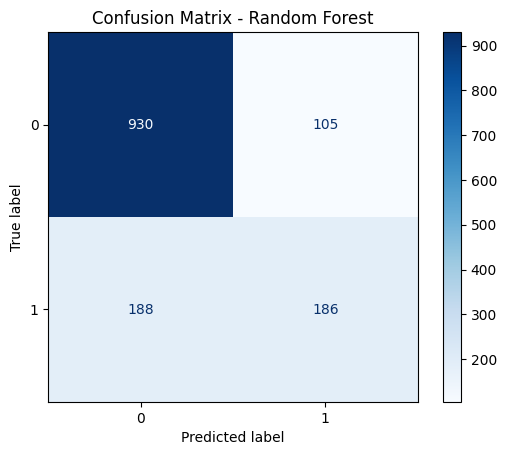

In [9]:
# Cell 9️ Plot confusion matrix for the best-performing model
from sklearn.metrics import ConfusionMatrixDisplay

best_model = rf  # assuming Random Forest performed best
y_pred = best_model.predict(X_test_scaled)

ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [10]:
# Cell 10 Save the trained model for reuse or deployment
import joblib

joblib.dump(best_model, "telco_churn_model.pkl")
print("✅ Model saved as telco_churn_model.pkl")


✅ Model saved as telco_churn_model.pkl


In [11]:
# Cell 11 Generate predictions for the full dataset

# Recreate full feature matrix and target
X_full = df_encoded.drop('Churn', axis=1)
y_full = df_encoded['Churn']

# Scale using the same fitted scaler from training
X_full_scaled = scaler.transform(X_full)

# Predict class and probability
full_pred = best_model.predict(X_full_scaled)
full_prob = best_model.predict_proba(X_full_scaled)[:, 1]

print("Predictions generated successfully.")
print("Total rows scored:", len(full_pred))

Predictions generated successfully.
Total rows scored: 7043


In [12]:
# Cell 12 Build enhanced predictions export file

# Helper functions
def risk_band(prob):
    if prob >= 0.80:
        return "Very High"
    elif prob >= 0.60:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    else:
        return "Low"

def retention_priority(prob):
    if prob >= 0.80:
        return "Urgent"
    elif prob >= 0.60:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    else:
        return "Low"

# Build export dataframe
predictions_df = pd.DataFrame({
    "customerID": customer_ids.reset_index(drop=True),
    "Actual_Churn": y_full.map({1: "Yes", 0: "No"}).reset_index(drop=True),
    "Predicted_Churn": pd.Series(full_pred).map({1: "Yes", 0: "No"}),
    "Churn_Probability": full_prob
})

# Add Power BI-friendly columns
predictions_df["Churn_Probability_Pct"] = (predictions_df["Churn_Probability"] * 100).round(2)
predictions_df["Risk_Band"] = predictions_df["Churn_Probability"].apply(risk_band)
predictions_df["Retention_Priority"] = predictions_df["Churn_Probability"].apply(retention_priority)
predictions_df["High_Risk_Flag"] = np.where(predictions_df["Churn_Probability"] >= 0.60, "Yes", "No")

# Optional sort by highest-risk customers first
predictions_df = predictions_df.sort_values(by="Churn_Probability", ascending=False).reset_index(drop=True)

print("Enhanced predictions preview:")
display(predictions_df.head(10))
print("Rows in export file:", len(predictions_df))

Enhanced predictions preview:


,customerID,Actual_Churn,Predicted_Churn,Churn_Probability,Churn_Probability_Pct,Risk_Band,Retention_Priority,High_Risk_Flag
0,0495-RVCBF,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
1,1761-AEZZR,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
2,2636-ALXXZ,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
3,0488-GSLFR,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
4,7254-IQWOZ,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
5,9728-FTTVZ,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
6,4510-HIMLV,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
7,2514-GINMM,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
8,9497-QCMMS,Yes,Yes,1.0,100.0,Very High,Urgent,Yes
9,7665-TOALD,Yes,Yes,1.0,100.0,Very High,Urgent,Yes


Rows in export file: 7043


In [13]:
# Cell 13 Export enhanced predictions CSV

output_file = "customer_churn_predictions_enhanced.csv"
predictions_df.to_csv(output_file, index=False)

print(f"✅ Enhanced predictions CSV saved as: {output_file}")

✅ Enhanced predictions CSV saved as: customer_churn_predictions_enhanced.csv


In [14]:
# Cell 14 Download the CSV
from google.colab import files
files.download("customer_churn_predictions_enhanced.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Cell 15 Export Top 100 highest churn risk customers

# Select top 100 customers by churn probability
top_risk_customers = predictions_df.sort_values(
    by="Churn_Probability",
    ascending=False
).head(100)

# Save to CSV
top_file = "top_100_high_risk_customers.csv"
top_risk_customers.to_csv(top_file, index=False)

print("Top 100 high-risk customers preview:")
display(top_risk_customers)

print(f"✅ Top risk customers CSV saved as: {top_file}")

Top 100 high-risk customers preview:


,customerID,Actual_Churn,Predicted_Churn,Churn_Probability,Churn_Probability_Pct,Risk_Band,Retention_Priority,High_Risk_Flag
0,0495-RVCBF,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
15,6457-GIRWB,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
14,6502-MJQAE,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
19,4603-JANFB,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
18,3428-XZMAZ,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
22,8375-DKEBR,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
21,7024-OHCCK,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
20,5550-VFRLC,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
17,8740-CRYFY,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes
5,9728-FTTVZ,Yes,Yes,1.000000,100.00,Very High,Urgent,Yes


✅ Top risk customers CSV saved as: top_100_high_risk_customers.csv


In [17]:
# Cell 17 Export model feature importance

import pandas as pd

# Check if the model supports feature importance
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    })

elif hasattr(best_model, "coef_"):

    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": abs(best_model.coef_[0])
    })

else:
    raise ValueError("Model does not support feature importance extraction")

# Sort most important features first
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Export CSV
importance_file = "churn_feature_importance.csv"
feature_importance.to_csv(importance_file, index=False)

print("Top model drivers of churn:")
display(feature_importance.head(15))

print(f"✅ Feature importance CSV saved as: {importance_file}")

Top model drivers of churn:


,Feature,Importance
0,TotalCharges,0.194123
1,tenure,0.171364
2,MonthlyCharges,0.167562
3,InternetService_Fiber optic,0.038864
4,PaymentMethod_Electronic check,0.038285
5,Contract_Two year,0.031477
6,gender_Male,0.028519
7,OnlineSecurity_Yes,0.027796
8,PaperlessBilling_Yes,0.025725
9,Partner_Yes,0.023285


✅ Feature importance CSV saved as: churn_feature_importance.csv


In [18]:
#Cell 18 Download Feature Importance
from google.colab import files
files.download("churn_feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>